In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/smart_factory_dataset.csv')

print("Dataset Head:")
display(df.head())
print("\nDataset Info:")
df.info()

Dataset Head:


,RPM,Vibration,Pressure,Machine_Mode,Temperature,Defective
0,1256,0.400,38.89,Eco,61.34,0
1,1926,0.502,38.13,Eco,70.99,0
2,1714,0.508,46.14,Eco,70.46,0
3,1219,0.404,36.29,High-Speed,69.50,0
4,1156,0.374,24.69,High-Speed,59.39,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RPM           1500 non-null   int64  
 1   Vibration     1500 non-null   float64
 2   Pressure      1500 non-null   float64
 3   Machine_Mode  1500 non-null   object 
 4   Temperature   1500 non-null   float64
 5   Defective     1500 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 70.4+ KB


In [40]:
X_simple = df[['RPM']]
y_simple = df['Temperature']

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train_simple)

y_pred_simple = model_simple.predict(X_test_simple)

mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
print(f"Mean Squared Error for Simple Linear Regression (RPM vs. Temperature): {mse_simple:.2f}")

Mean Squared Error for Simple Linear Regression (RPM vs. Temperature): 46.30


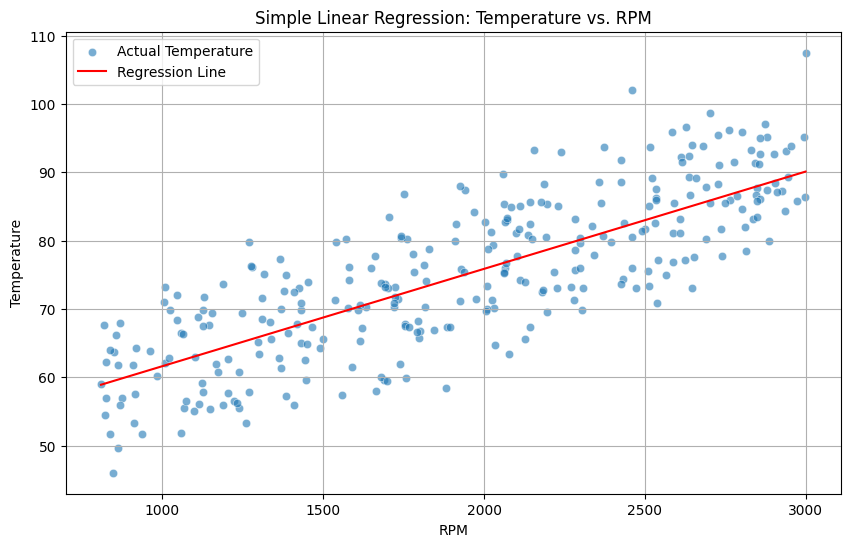

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_simple['RPM'], y=y_test_simple, alpha=0.6, label='Actual Temperature')
sns.lineplot(x=X_test_simple['RPM'], y=y_pred_simple, color='red', label='Regression Line')
plt.title('Simple Linear Regression: Temperature vs. RPM')
plt.xlabel('RPM')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
X_multi = df[['RPM', 'Vibration', 'Pressure']]
y_multi = df['Temperature']

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

y_pred_multi = model_multi.predict(X_test_multi)

mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
print(f"Mean Squared Error for Multivariable Linear Regression: {mse_multi:.2f}")

print(f"\nSimple Linear Regression MSE: {mse_simple:.2f}")
print(f"Multivariable Linear Regression MSE: {mse_multi:.2f}")

if mse_multi < mse_simple:
    print("Adding more features (Vibration, Pressure) has reduced the Mean Squared Error, indicating an improved model performance.")
else:
    print("Adding more features did not significantly reduce the Mean Squared Error. This might indicate that the additional features are not highly predictive of temperature, or there might be multicollinearity.")

Mean Squared Error for Multivariable Linear Regression: 35.55

Simple Linear Regression MSE: 46.30
Multivariable Linear Regression MSE: 35.55
Adding more features (Vibration, Pressure) has reduced the Mean Squared Error, indicating an improved model performance.


In [42]:
import joblib

model_filename = 'multivariable_linear_model.joblib'

joblib.dump(model_multi, model_filename)

print(f"Multivariable linear regression model saved as '{model_filename}'")

Multivariable linear regression model saved as 'multivariable_linear_model.joblib'


In [43]:
import pandas as pd
import joblib

loaded_model = joblib.load(model_filename)
print(f"Model '{model_filename}' loaded successfully.")

mock_new_reading = pd.DataFrame({
    'RPM': [1100],
    'Vibration': [35],
    'Pressure': [95]
})

print("\nMock new machine reading:")
display(mock_new_reading)

predicted_temperature = loaded_model.predict(mock_new_reading)

print(f"\nPredicted Temperature for the mock reading: {predicted_temperature[0]:.2f} Celsius")

Model 'multivariable_linear_model.joblib' loaded successfully.

Mock new machine reading:


,RPM,Vibration,Pressure
0,1100,35,95



Predicted Temperature for the mock reading: 918.49 Celsius


In [44]:
from sklearn.preprocessing import OneHotEncoder

categorical_column = ['Machine_Mode']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_features = encoder.fit_transform(df[categorical_column])

encoded_feature_names = encoder.get_feature_names_out(categorical_column)

df_encoded_modes = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df.index)

df_processed = pd.concat([df.drop(columns=categorical_column), df_encoded_modes], axis=1)

print("Original DataFrame head:")
display(df.head())
print("\nProcessed DataFrame head with One-Hot Encoded features:")
display(df_processed.head())
print("\nUnique values in original 'Machine_Mode' column:", df['Machine_Mode'].unique())
print("Encoded feature names (before dropping a dummy variable):", encoded_feature_names)

Original DataFrame head:


,RPM,Vibration,Pressure,Machine_Mode,Temperature,Defective
0,1256,0.400,38.89,Eco,61.34,0
1,1926,0.502,38.13,Eco,70.99,0
2,1714,0.508,46.14,Eco,70.46,0
3,1219,0.404,36.29,High-Speed,69.50,0
4,1156,0.374,24.69,High-Speed,59.39,0



Processed DataFrame head with One-Hot Encoded features:


,RPM,Vibration,Pressure,Temperature,Defective,Machine_Mode_Eco,Machine_Mode_High-Speed,Machine_Mode_Standard
0,1256,0.400,38.89,61.34,0,1.0,0.0,0.0
1,1926,0.502,38.13,70.99,0,1.0,0.0,0.0
2,1714,0.508,46.14,70.46,0,1.0,0.0,0.0
3,1219,0.404,36.29,69.50,0,0.0,1.0,0.0
4,1156,0.374,24.69,59.39,0,0.0,1.0,0.0



Unique values in original 'Machine_Mode' column: ['Eco' 'High-Speed' 'Standard']
Encoded feature names (before dropping a dummy variable): ['Machine_Mode_Eco' 'Machine_Mode_High-Speed' 'Machine_Mode_Standard']


In [45]:
X_temp_split = df_processed.drop(columns=['Temperature', 'Defective'])
y_temp_split = df_processed['Temperature']

X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X_temp_split, y_temp_split, test_size=0.2, random_state=42)

print(f"Shape of X_train (Temperature prediction): {X_train_temp.shape}")
print(f"Shape of X_test (Temperature prediction): {X_test_temp.shape}")
print(f"Shape of y_train (Temperature prediction): {y_train_temp.shape}")
print(f"Shape of y_test (Temperature prediction): {y_test_temp.shape}")

model_temp_split = LinearRegression()
model_temp_split.fit(X_train_temp, y_train_temp)

y_train_pred_temp = model_temp_split.predict(X_train_temp)
y_test_pred_temp = model_temp_split.predict(X_test_temp)

mse_train_split_temp = mean_squared_error(y_train_temp, y_train_pred_temp)
mse_test_split_temp = mean_squared_error(y_test_temp, y_test_pred_temp)

print(f"\nMean Squared Error on Training Set (Temperature prediction): {mse_train_split_temp:.2f}")
print(f"Mean Squared Error on Test Set (Temperature prediction): {mse_test_split_temp:.2f}")

Shape of X_train (Temperature prediction): (1200, 6)
Shape of X_test (Temperature prediction): (300, 6)
Shape of y_train (Temperature prediction): (1200,)
Shape of y_test (Temperature prediction): (300,)

Mean Squared Error on Training Set (Temperature prediction): 8.77
Mean Squared Error on Test Set (Temperature prediction): 9.07


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

X_defective = df_processed.drop(columns=['Defective'])
y_defective = df_processed['Defective']

X_train_def, X_test_def, y_train_def, y_test_def = train_test_split(X_defective, y_defective, test_size=0.2, random_state=42, stratify=y_defective)

print(f"Shape of X_train (Defective prediction): {X_train_def.shape}")
print(f"Shape of X_test (Defective prediction): {X_test_def.shape}")
print(f"Shape of y_train (Defective prediction): {y_train_def.shape}")
print(f"Shape of y_test (Defective prediction): {y_test_def.shape}")

model_defective = LogisticRegression(solver='liblinear', random_state=42)
model_defective.fit(X_train_def, y_train_def)

y_pred_def = model_defective.predict(X_test_def)

accuracy = accuracy_score(y_test_def, y_pred_def)
print(f"\nAccuracy of Logistic Regression Model: {accuracy:.2f}")

Shape of X_train (Defective prediction): (1200, 7)
Shape of X_test (Defective prediction): (300, 7)
Shape of y_train (Defective prediction): (1200,)
Shape of y_test (Defective prediction): (300,)

Accuracy of Logistic Regression Model: 0.96


Confusion Matrix:
 [[252   3]
 [ 10  35]]


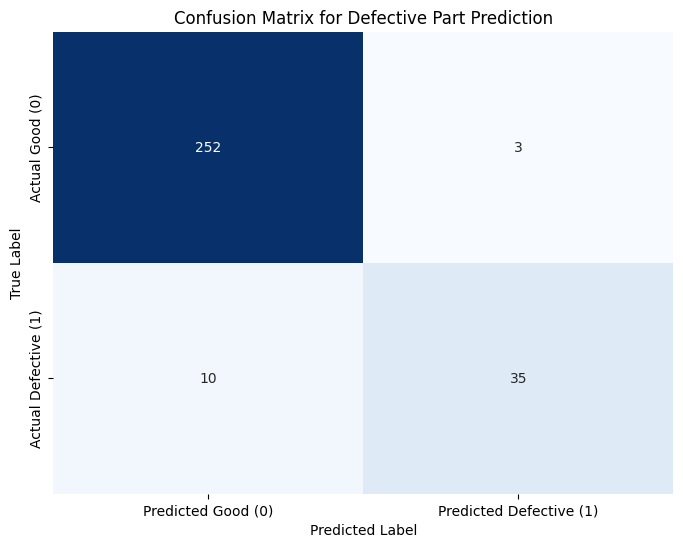


True Negatives (Correctly predicted Good): 252
False Positives (Incorrectly predicted Defective, Actual Good): 3
False Negatives (Incorrectly predicted Good, Actual Defective): 10
True Positives (Correctly predicted Defective): 35

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       255
           1       0.92      0.78      0.84        45

    accuracy                           0.96       300
   macro avg       0.94      0.88      0.91       300
weighted avg       0.96      0.96      0.96       300



In [47]:
import numpy as np

cm = confusion_matrix(y_test_def, y_pred_def)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Good (0)', 'Predicted Defective (1)'],
            yticklabels=['Actual Good (0)', 'Actual Defective (1)'])
plt.title('Confusion Matrix for Defective Part Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives (Correctly predicted Good): {tn}")
print(f"False Positives (Incorrectly predicted Defective, Actual Good): {fp}")
print(f"False Negatives (Incorrectly predicted Good, Actual Defective): {fn}")
print(f"True Positives (Correctly predicted Defective): {tp}")

print("\nClassification Report:\n", classification_report(y_test_def, y_pred_def))

In [48]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

X = X_temp_split
y = y_temp_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

learning_rates = [0.00001, 0.001, 0.1, 1.0]
mse_results = {}

print("\n--- SGDRegressor with Different Learning Rates ---")

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    sgd_model = SGDRegressor(max_iter=1000, eta0=lr, random_state=42, tol=None)
    sgd_model.fit(X_train_scaled, y_train)

    y_pred_train = sgd_model.predict(X_train_scaled)
    y_pred_test = sgd_model.predict(X_test_scaled)

    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)

    mse_results[lr] = {'train': mse_train, 'test': mse_test}

    print(f"  Training MSE: {mse_train:.2f}")
    print(f"  Test MSE: {mse_test:.2f}")

print("\n--- Summary of MSE results ---")
for lr, mse in mse_results.items():
    print(f"Learning Rate {lr}: Training MSE = {mse['train']:.2f}, Test MSE = {mse['test']:.2f}")


--- SGDRegressor with Different Learning Rates ---

Training with learning rate: 1e-05
  Training MSE: 2192.04
  Test MSE: 2197.57

Training with learning rate: 0.001
  Training MSE: 8.77
  Test MSE: 9.07

Training with learning rate: 0.1
  Training MSE: 8.78
  Test MSE: 9.12

Training with learning rate: 1.0
  Training MSE: 9.54
  Test MSE: 9.79

--- Summary of MSE results ---
Learning Rate 1e-05: Training MSE = 2192.04, Test MSE = 2197.57
Learning Rate 0.001: Training MSE = 8.77, Test MSE = 9.07
Learning Rate 0.1: Training MSE = 8.78, Test MSE = 9.12
Learning Rate 1.0: Training MSE = 9.54, Test MSE = 9.79
